# 09 · Interpretation — what drives the rent, in plain words
### The Outliers · Mumbai Rent Radar

A model a pricing team can act on has to be *explainable*. We answer three questions:
**which features move rent**, **how** each one moves it, and **what an upgrade is worth**
in rupees — the language a landlord or renter actually uses.

**Input:** `final_model.joblib`, shared `model_data.csv`

In [2]:
import sys, warnings, joblib
sys.path.append("../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import style
warnings.filterwarnings("ignore")
style.setup()

art = joblib.load("../data/processed/final_model.joblib")
pipe, NUM, CAT = art["pipe"], art["num"], art["cat"]
d = pd.read_csv("../data/processed/model_data.csv")
X, y = d[NUM + CAT], d["log_rent"]
Xte, yte = X[~d.is_train], y[~d.is_train]

## 1 · Which features actually move the price?
Permutation importance: shuffle one feature, measure how much accuracy falls. Model-agnostic
and honest — it credits a feature only if the model truly relies on it.

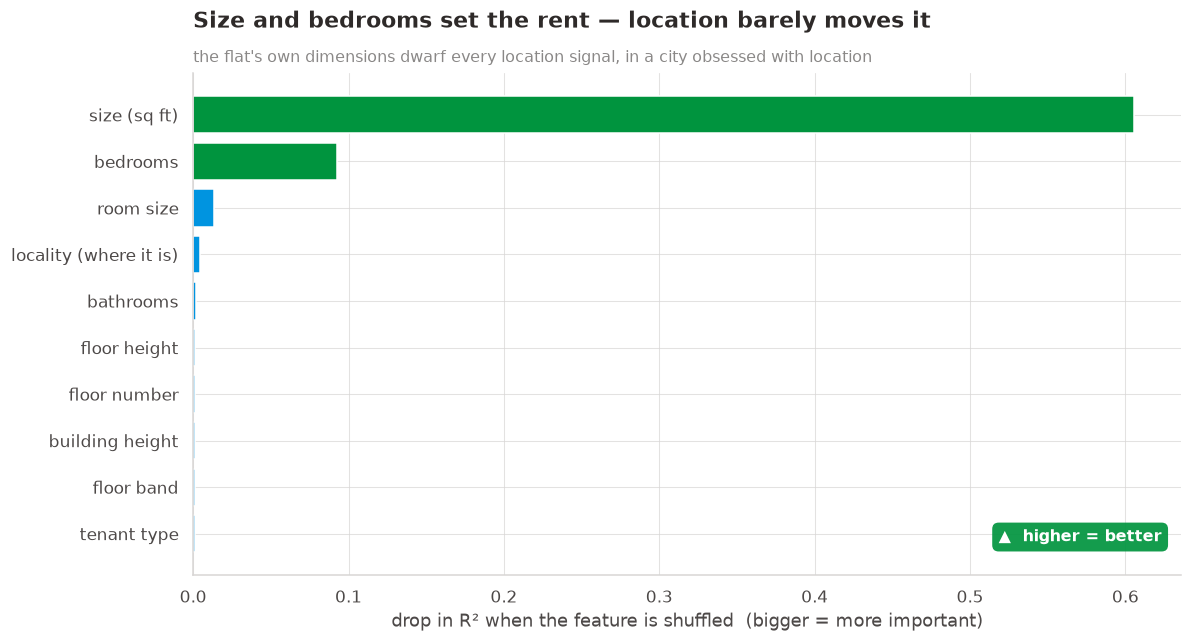

In [3]:
pi = permutation_importance(pipe, Xte, yte, n_repeats=10, random_state=42, n_jobs=1)
imp = pd.Series(pi.importances_mean, index=NUM + CAT).sort_values()
pretty = {"locality_te": "locality (where it is)", "size": "size (sq ft)", "bhk": "bedrooms",
          "bathroom": "bathrooms", "size_per_bhk": "room size", "floor_ratio": "floor height",
          "total_floors": "building height", "bath_per_bhk": "baths per BHK",
          "furnishing_status": "furnishing", "floor_num": "floor number",
          "area_type": "area type", "point_of_contact": "agent vs owner",
          "tenant_preferred": "tenant type", "zone": "zone", "is_tall_building": "tall building",
          "floor_band": "floor band"}
imp = imp[imp > 0.0005]
fig, ax = plt.subplots(figsize=(11, 6))
colors = [style.GREEN if i in ("size", "bhk") else style.BLUE for i in imp.index]
ax.barh([pretty.get(i, i) for i in imp.index], imp.values, color=colors)
ax.set_xlabel("drop in R² when the feature is shuffled  (bigger = more important)")
style.title(ax, "Size and bedrooms set the rent — location barely moves it",
            "the flat's own dimensions dwarf every location signal, in a city obsessed with location")
style.direction_badge(ax, "higher", "lower right")
fig.tight_layout(); style.save(fig, "09_permutation_importance"); plt.show()

**Insight:** **size** dwarfs everything, **bedrooms** second; every location signal — including
the engineered locality — is minor. This confirms the diagnostic story with the model's own
behaviour: in a city obsessed with location, the flat's dimensions set the rent. **Decision:**
the memo leads with size and bedrooms; location fine-tunes the baseline.

## 2 · *How* does each lever move rent? Partial dependence
Holding everything else fixed, how predicted rent responds as one feature changes.

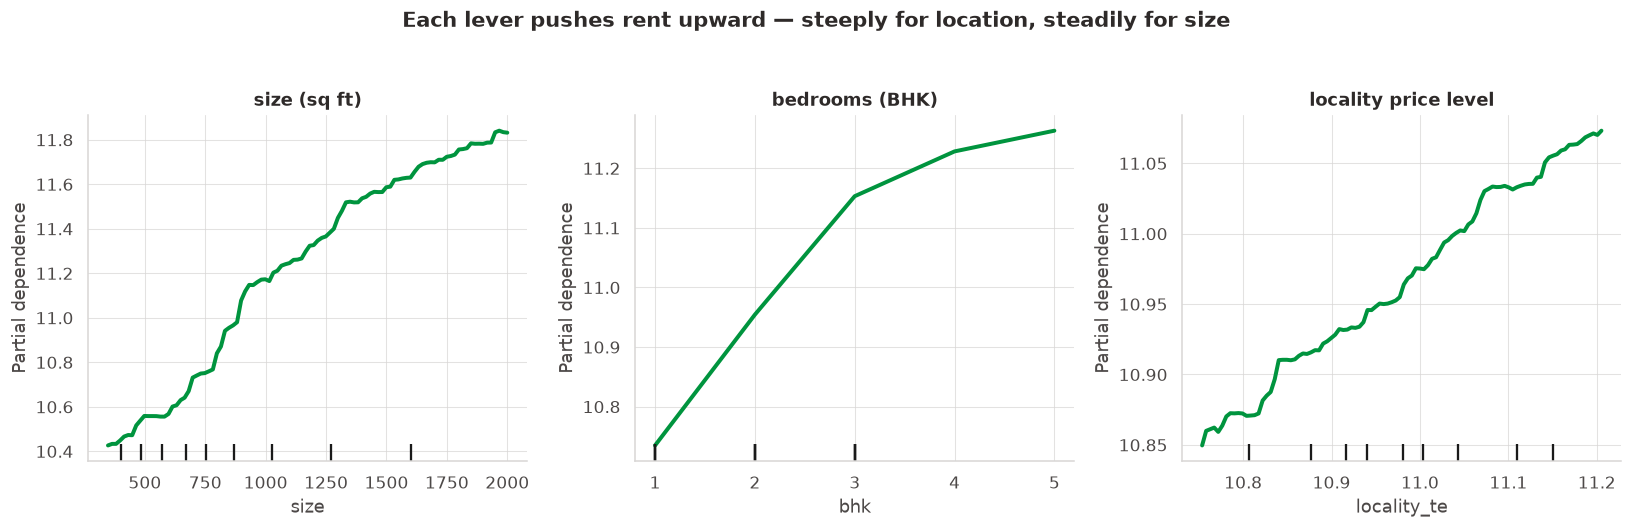

In [4]:
Xpdp = Xte.copy()
Xpdp[NUM] = Xpdp[NUM].astype(float)   # PDP requires float numeric columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, feat, lab in [(axes[0], "size", "size (sq ft)"),
                      (axes[1], "bhk", "bedrooms (BHK)"),
                      (axes[2], "locality_te", "locality price level")]:
    PartialDependenceDisplay.from_estimator(pipe, Xpdp, [feat], ax=ax, line_kw={"color": style.GREEN, "lw": 2.6})
    ax.set_title(lab, fontsize=12, fontweight="bold", color=style.INK)
    ax.set_ylabel("effect on log(rent)")
fig.suptitle("Each lever pushes rent upward — steeply for location, steadily for size",
             fontsize=14, fontweight="bold", color=style.INK, y=1.04)
fig.tight_layout(); style.save(fig, "09_partial_dependence"); plt.show()

## 3 · What is an upgrade worth? (in rupees)
We take a typical mid-market flat and change one thing at a time, reading the rent change
straight off the model. This is the "what's a balcony in Indiranagar worth?" answer.

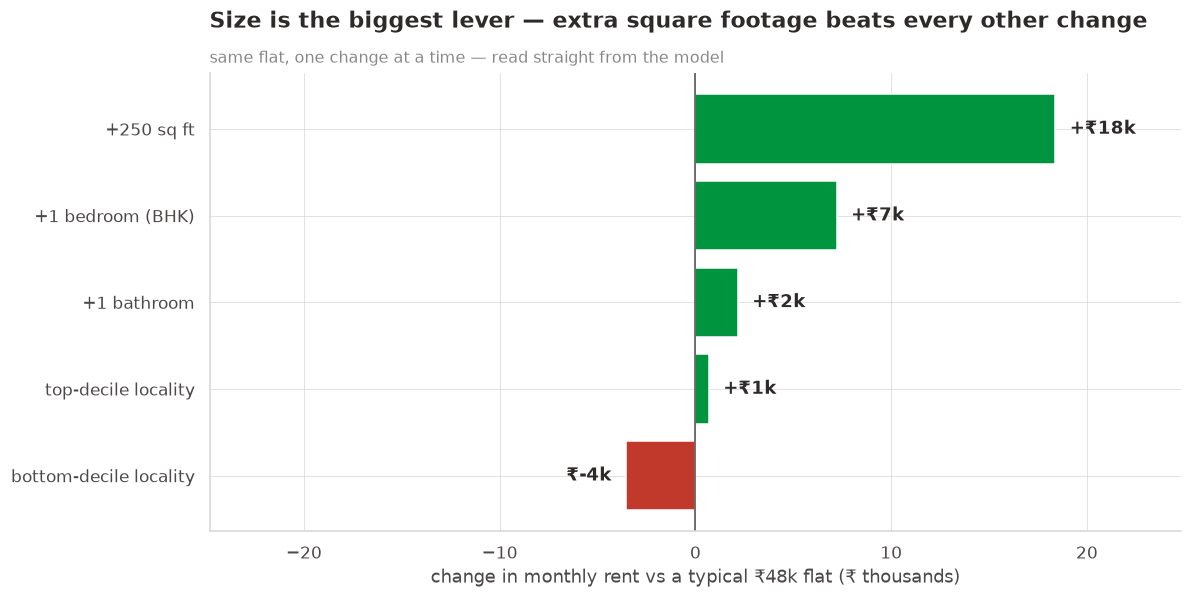

In [5]:
base_row = Xte.median(numeric_only=True)
typical = Xte.copy().iloc[[0]]
for c in NUM: typical[c] = base_row[c]
base_pred = np.exp(pipe.predict(typical))[0]

scenarios = []
def whatif(label, **changes):
    row = typical.copy()
    for k, v in changes.items(): row[k] = v
    new = np.exp(pipe.predict(row))[0]
    scenarios.append((label, (new - base_pred)))

whatif("+1 bathroom", bathroom=base_row["bathroom"] + 1)
whatif("+1 bedroom (BHK)", bhk=base_row["bhk"] + 1)
whatif("+250 sq ft", size=base_row["size"] + 250)
whatif("top-decile locality", locality_te=d["locality_te"].quantile(0.9))
whatif("bottom-decile locality", locality_te=d["locality_te"].quantile(0.1))

sc = pd.Series(dict(scenarios)).sort_values()
fig, ax = plt.subplots(figsize=(11, 5.6))
colors = [style.BAD if v < 0 else style.GREEN for v in sc.values]
ax.barh(sc.index, sc.values / 1000, color=colors)
xmax = max(abs(sc.min()), abs(sc.max())) / 1000
for i, v in enumerate(sc.values):
    off = xmax * 0.04
    ax.text(v / 1000 + (off if v >= 0 else -off), i, f"{'+' if v>=0 else ''}₹{v/1000:.0f}k",
            va="center", ha="left" if v >= 0 else "right", fontweight="bold", color=style.INK)
ax.axvline(0, color=style.CHARCOAL, lw=1)
ax.set_xlim(-xmax * 1.35, xmax * 1.35)
ax.set_xlabel(f"change in monthly rent vs a typical ₹{base_pred/1000:.0f}k flat (₹ thousands)")
style.title(ax, "Size is the biggest lever — extra square footage beats every other change",
            "same flat, one change at a time — read straight from the model")
fig.tight_layout(); style.save(fig, "09_what_is_it_worth"); plt.show()

**Insight:** on a typical mid-market flat, **adding space moves rent far more than moving
address** — 250 sq ft is worth more than an extra bedroom, a bathroom, or a jump to a
top-decile locality. Location sets the baseline; size is what a renter is really paying for.

## 4 · SHAP: how features push an individual prediction (bonus)
SHAP splits a single prediction into per-feature contributions — the most granular "why".

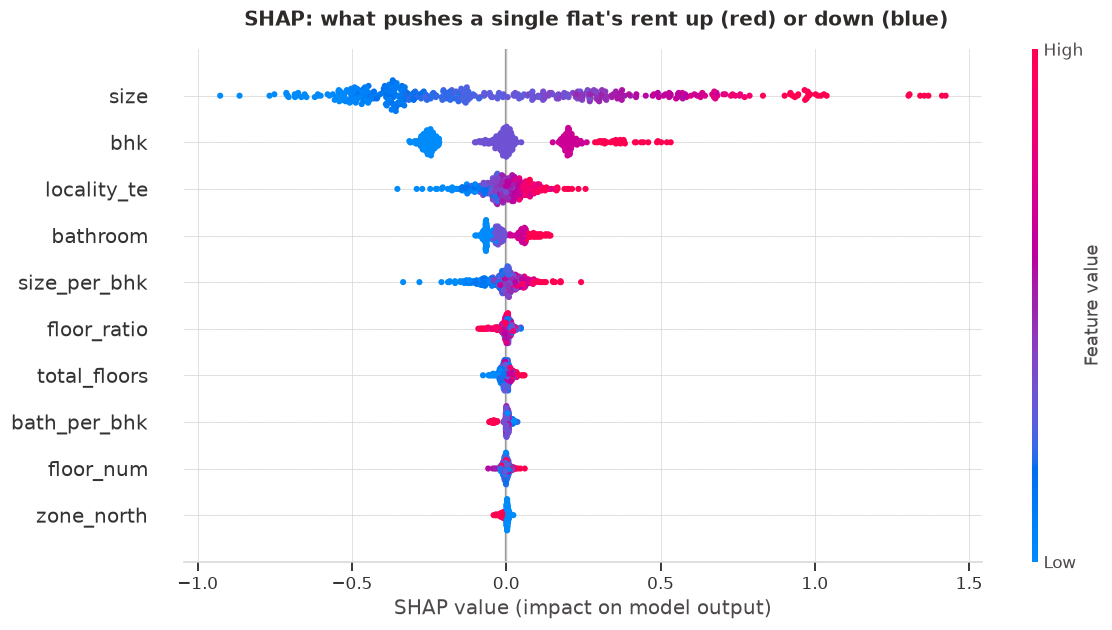

SHAP summary rendered.


In [6]:
try:
    import shap
    pre = pipe.named_steps["pre"]; rf = pipe.named_steps["mdl"]
    Xt = pre.transform(Xte.sample(400, random_state=1))
    names = pre.get_feature_names_out()
    expl = shap.TreeExplainer(rf)
    sv = expl.shap_values(Xt)
    plt.figure()
    shap.summary_plot(sv, features=Xt, feature_names=[n.split("__")[-1] for n in names],
                      show=False, max_display=10, plot_size=(11, 5.6))
    fig = plt.gcf(); fig.suptitle("SHAP: what pushes a single flat's rent up (red) or down (blue)",
                                  fontsize=13, fontweight="bold", color=style.INK, y=1.02)
    style.save(fig, "09_shap_summary"); plt.show()
    print("SHAP summary rendered.")
except Exception as e:
    print("SHAP step skipped:", e.__class__.__name__, "-", e)

### Interpretation takeaways
- **Size and bedrooms are the whole story;** every location signal is a minor lever. This
  matches the diagnostics and the model's own permutation test — a consistent, honest narrative.
- **The biggest lever is square footage,** not the address — surprising for Mumbai, but the
  what-if analysis is unambiguous.
- **Upgrades priced in rupees** give the pricing team ready-made talking points.